# Nucl.Eye.D — pretrained nucleus & chromocenter segmentation on one DAPI image (minimal reproduction)

**Paper:** G. Schivre et al., *"Advanced Image Analysis Methods for Automated Segmentation of Subnuclear Chromatin Domains"*, **Epigenomes 6(4):34 (2022)**, DOI [10.3390/epigenomes6040034](https://doi.org/10.3390/epigenomes6040034) — open access (CC BY), PMC9624336.

**Released artifact (paper ref. [41]):** Zenodo record [7075507](https://zenodo.org/records/7075507) (CC BY-4.0), containing `The_Nucl_Eye_D.ipynb` (author release notebook), `Supplemental Macros.zip` and `nucleyed.zip` (4.56 GB; trained models + training data + all images).

**Scope of this notebook (single example):** run the authors' pretrained **Nucl.Eye.D** chained U-Nets (Region-Proposal → Nucleus → Chromocenter) on **one** DAPI z-max-projection image (`Dark_0.png`) from the archive's Light/Dark test set (`nucleyed/input/Light_Drak/Img/images`, 51 images; paper Section 2.3), visualize predicted masks against the reference masks shipped in the archive, and compute the paper's morphometric parameters **HF, RHI, RHF** (Section 3.7) from the predicted masks. Training, batch processing, dataset-level statistics and the iCRAQ ImageJ macro tool are **out of scope**.

**Execution status:** executed and validated on Google Colab (**CPU runtime** — the measured inference time on one image is a few seconds). A T4 GPU runs the same cells unchanged but is optional for this demonstration and was not separately required; the notebook reports the hardware actually used. Inference on one image takes a few seconds; the main cost is the ~520 MB model download (ranged partial fetch of the 4.56 GB archive).

**AI-assisted adaptation notice (EN):** this notebook was assembled from the authors' released materials; the core segmentation functions are copied **verbatim** from the authors' `The_Nucl_Eye_D.ipynb`. The authors' release notebook reads inputs from Google Drive; here the same pinned Zenodo files are fetched directly into the Colab VM, and the authors' batch `PredictSet` loop is adapted to a single in-memory image. The HF/RHI/RHF quantification is a Python implementation of the paper's Section 3.7 formulas (the authors computed them with ImageJ macros in `Supplemental Macros.zip`). Untested behavior beyond the executed example is not guaranteed.
**AI支援に関する注意（JP）：** 本ノートブックは著者公開コード（Zenodo 7075507）を基に構成しました。核・クロモセンター推論は著者コードの逐語コピー、入力取得はZenodoからの直接ダウンロード（Drive不要）、HF/RHI/RHF計算は論文Section 3.7の定義のPython実装（著者はImageJマクロ使用）です。実行例以外の動作は保証されません。

## Runtime selection and how to run

**Select the runtime:** `Runtime > Change runtime type` — **CPU is the recommended and validated runtime** for this single-image demo (~3 s inference; the main cost is the ~520 MB model download). A **T4 GPU** runs the exact same cells faster, but is optional and was not required for this demonstration. The notebook detects the allocated hardware automatically.

**Run:** `Runtime > Run all`. Expected total time ≈ 10–20 min, dominated by the partial download of the three trained-model directories (~518 MB) from Zenodo via HTTP Range requests (no full 4.56 GB archive download unless the ranged route fails — a documented fallback then downloads the full archive once, md5-checked, and only extracts the same members).

**Expected result:** one DAPI nucleus image segmented into nucleus + chromocenter masks, a comparison against the reference masks shipped in the archive, and a small HF/RHI/RHF metrics table.

**実行時間の目安（JP）：** 全体で約10〜20分（モデル約518MBの部分ダウンロードが主体）。推論自体はCPUで数秒です。T4 GPUでも同じセルがそのまま動作します（必須ではありません）。

Check the environment and whether a GPU is allocated. No hardware choice is imposed; the same pipeline runs on CPU or GPU.

In [ ]:
import sys, time, platform
print("Python:", sys.version.split()[0], "| platform:", platform.machine())
import tensorflow as tf
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus if gpus else "none (CPU runtime - fine for this single-image demo)")
import skimage, scipy, pandas, numpy, PIL, matplotlib
print("scikit-image:", skimage.__version__, "| numpy:", numpy.__version__, "| pandas:", pandas.__version__)

Python: 3.13.16 | platform: x86_64


TensorFlow: 2.21.0
GPUs detected: none (CPU runtime - fine for this single-image demo)
scikit-image: 0.25.2 | numpy: 2.1.3 | pandas: 2.2.3


## Dependency setup

The three pretrained models are stored as **legacy Keras SavedModel directories** (`saved_model.pb` + `variables/`, saved by Keras 2). Modern Colab TensorFlow (Keras 3) refuses this legacy format, so we install the official **`tf-keras`** compatibility package (the maintained Keras 2 implementation) **without dependencies** (`--no-deps`) so the preinstalled TensorFlow/GPU stack is left untouched. All other packages used here (scikit-image, scipy, pandas, Pillow, matplotlib) are preinstalled on Colab.

**依存関係（JP）：** モデルは旧形式SavedModelのため、Keras 2互換の公式パッケージ `tf-keras` を `--no-deps` で追加導入します（既存のTF/GPU環境は変更しません）。

In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable, "-m", "pip", "install", "--no-deps", "-q", "tf-keras"],
                   capture_output=True, text=True)
if r.returncode != 0:
    raise RuntimeError("tf-keras install failed:\n" + r.stderr[-1000:])
import tf_keras
print("tf-keras", tf_keras.__version__, "(Keras 2 legacy loader for the authors' SavedModel directories)")

tf-keras 2.21.0 (Keras 2 legacy loader for the authors' SavedModel directories)


## Input & weights acquisition (pinned provenance)

Everything is downloaded **inside this notebook, onto the Colab VM** (`/content`) — nothing is read from the host. The paper's models exist **only inside `nucleyed.zip` (4.56 GB, md5 `c1a68585ea2c77ad7c8bb3f95cbeaf01`, Zenodo record 7075507)**. Instead of downloading the whole archive, we read its **zip central directory over HTTP Range requests** and fetch **only** the three SavedModel directories (`nucleyed/output/models/The_TMI_{RPN,NM,CC}_Model/`) plus the demo image and its two reference masks from the archive's Light/Dark test set `nucleyed/input/Light_Drak/`:

- `Img/images/Dark_0.png` — the demo DAPI z-max-projection (deterministic choice: first sorted of the 51 test images; the authors' default prediction path `Philippe-DL-TEST` is not present in the released archive),
- `Nuc/Mask/masks/Dark_0.png` and `CC/Mask/masks/Dark_0.png` — reference nucleus/chromocenter masks shipped with the archive.

Every member's size is verified against the zip entry metadata (zip CRC is checked by `zipfile` on read). SHA-256 values are printed for provenance. If Zenodo rejects ranged access, the documented fallback downloads the full archive once, verifies its md5, and extracts only the same members.

**入手方法（JP）：** 4.56GBアーカイブ全体ではなく、HTTP Rangeでzip中央ディレクトリを読み、必要な3モデル+デモ画像+参照マスクのみ取得します（失敗時はフルダウンロード+md5検証のフォールバック）。

In [ ]:
import requests, io, zipfile, os, shutil, hashlib, time

URL = "https://zenodo.org/api/records/7075507/files/nucleyed.zip/content"
EXPECTED_ZIP_MD5 = "c1a68585ea2c77ad7c8bb3f95cbeaf01"
S = requests.Session()

class HTTPRangeFile(io.RawIOBase):
    """Minimal read/seek file object backed by HTTP Range requests (zip central-directory access)."""
    def __init__(self, url):
        self.url, self.pos, self._size = url, 0, None
    @property
    def size(self):
        if self._size is None:
            r = S.get(self.url, headers={"Range": "bytes=0-0"}, allow_redirects=True, timeout=120)
            cr = r.headers.get("Content-Range")
            if not cr:
                raise RuntimeError(f"server did not honour Range requests (HTTP {r.status_code})")
            self._size = int(cr.split("/")[-1])
        return self._size
    def read(self, n=-1):
        if n is None or n < 0: n = self.size - self.pos
        if n == 0: return b""
        end = min(self.pos + n - 1, self.size - 1)
        r = S.get(self.url, headers={"Range": f"bytes={self.pos}-{end}"}, allow_redirects=True, timeout=600)
        r.raise_for_status(); data = r.content; self.pos += len(data); return data
    def seek(self, offset, whence=0):
        if whence == 0: self.pos = offset
        elif whence == 1: self.pos += offset
        else: self.pos = self.size + offset
        return self.pos
    def tell(self): return self.pos
    def seekable(self): return True
    def readable(self): return True

t0 = time.time()
try:
    zf = zipfile.ZipFile(HTTPRangeFile(URL))
    print("Ranged access to nucleyed.zip OK (archive size", zf.fp.size // 10**6, "MB).")
except Exception as e:
    print("Ranged access failed (", type(e).__name__, str(e)[:200], ") -> documented fallback: full 4.56 GB download + md5 check.")
    h = hashlib.md5()
    total = 0
    with S.get(URL, stream=True, timeout=3600, allow_redirects=True) as r:
        r.raise_for_status()
        with open("/content/nucleyed.zip", "wb") as f:
            for chunk in r.iter_content(8 * 1024 * 1024):
                f.write(chunk)
                h.update(chunk)
                total += len(chunk)
                if total % (500 * 10**6) < len(chunk):
                    print(f"  downloaded {total/10**9:.2f} GB ...", flush=True)
    digest = h.hexdigest()
    assert digest == EXPECTED_ZIP_MD5, f"nucleyed.zip md5 mismatch: {digest}"
    print("full archive downloaded,", total / 10**9, "GB, md5 verified.")
    zf = zipfile.ZipFile("/content/nucleyed.zip")

names = zf.namelist()
print("zip members:", len(names))

def fetch_member(name, dest):
    with zf.open(name) as src, open(dest, "wb") as out:
        shutil.copyfileobj(src, out, 1024 * 1024)
    expected = zf.getinfo(name).file_size
    got = os.path.getsize(dest)
    assert got == expected, f"{dest}: {got} != zip entry size {expected}"
    return got

MODEL_PREFS = {
    "The_TMI_RPN_Model": "nucleyed/output/models/The_TMI_RPN_Model/",
    "The_TMI_NM_Model":  "nucleyed/output/models/The_TMI_NM_Model/",
    "The_TMI_CC_Model":  "nucleyed/output/models/The_TMI_CC_Model/",
}
shutil.rmtree("/content/models", ignore_errors=True)
os.makedirs("/content/models", exist_ok=True)
for m, pref in MODEL_PREFS.items():
    members = [n for n in names if n.startswith(pref) and not n.endswith("/")]
    assert members, f"model directory {m} not found in archive"
    total = 0
    for n in members:
        rel = os.path.join("/content/models", m, os.path.relpath(n, pref))
        os.makedirs(os.path.dirname(rel), exist_ok=True)
        total += fetch_member(n, rel)
    print(f"{m}: {len(members)} members, {total/10**6:.1f} MB")

test_imgs = sorted(n for n in names if n.startswith("nucleyed/input/Light_Drak/Img/images/") and not n.endswith("/"))
sample_remote = test_imgs[0]
assert sample_remote.endswith("Dark_0.png"), sample_remote
print("test images in Light_Drak:", len(test_imgs), "| demo sample:", sample_remote.split("/")[-1])

def fetch_sha(name, dest):
    n = fetch_member(name, dest)
    h = hashlib.sha256()
    with open(dest, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return n, h.hexdigest()

sample_local = "/content/sample_Dark_0.png"
sz, sample_sha = fetch_sha(sample_remote, sample_local)
ref_nuc_remote = sorted(n for n in names if n.startswith("nucleyed/input/Light_Drak/Nuc/Mask/masks/") and n.endswith("Dark_0.png"))[0]
ref_cc_remote  = sorted(n for n in names if n.startswith("nucleyed/input/Light_Drak/CC/Mask/masks/") and n.endswith("Dark_0.png"))[0]
ref_nuc_local = "/content/reference_nuc_Dark_0.png"
ref_cc_local  = "/content/reference_CC_Dark_0.png"
_, ref_nuc_sha = fetch_sha(ref_nuc_remote, ref_nuc_local)
_, ref_cc_sha  = fetch_sha(ref_cc_remote, ref_cc_local)
print(f"sample {sample_remote.split('/')[-1]}: {sz} bytes, sha256 {sample_sha}")
print(f"reference nucleus mask: {ref_nuc_remote.split('/')[-1]}, sha256 {ref_nuc_sha}")
print(f"reference CC mask:      {ref_cc_remote.split('/')[-1]}, sha256 {ref_cc_sha}")
print("acquisition time:", round(time.time() - t0, 1), "s")

Ranged access to nucleyed.zip OK (archive size 4561 MB).
zip members: 3056


The_TMI_RPN_Model: 4 members, 339.6 MB


The_TMI_NM_Model: 4 members, 89.4 MB


The_TMI_CC_Model: 4 members, 89.4 MB
test images in Light_Drak: 51 | demo sample: Dark_0.png


sample Dark_0.png: 648968 bytes, sha256 734f183271d3ce53ee6fd01b9d5543e60d52c24c0ae9a640a9e4d1fdd626eeca
reference nucleus mask: Dark_0.png, sha256 fe48cc6e7626c15b5c5aca447f57f44ef547ee3a2b4ae41c51f9ed6736c2b6b6
reference CC mask:      Dark_0.png, sha256 713824dc770d9b7ea67a19301bb97c4b1eefc5bcfccbb7ccc7a6eea5fe02dda5
acquisition time: 429.7 s


## Input preview — the demo DAPI image

The demo input is `Dark_0.png` (1024×1024 RGB PNG): a **maximum-intensity z-projection** of a DAPI-stained *Arabidopsis thaliana* cotyledon nuclei from the paper's **Dark** growth condition (paper Section 2.3/3.7: acquisitions were reconstructed with ImageJ's *z max* plugin). This field contains **three nuclei**. Dark-grown nuclei have less conspicuous, more complex heterochromatin than Light-grown ones — exactly the hard case the paper highlights. Shown before any analysis, as shipped in the archive.

**入力プレビュー（JP）：** Dark条件のDAPI z最大投影画像（1024×1024）。解析前に実際の入力を表示します。

input array: (1024, 1024) float64 range 0.00392156862745098 - 0.9882352941176471


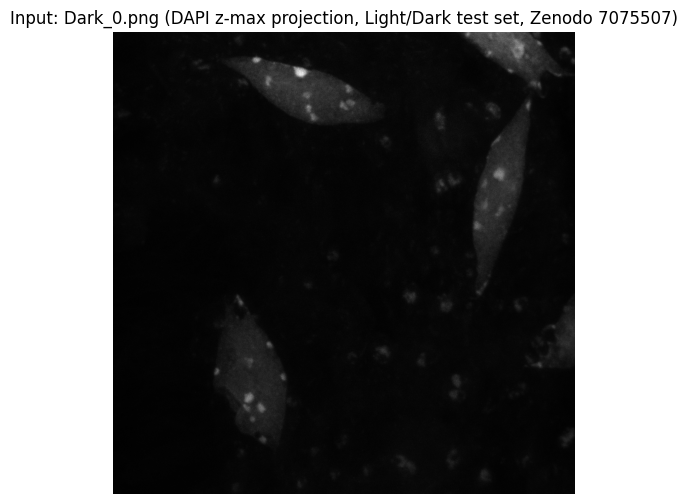

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray

raw = imread("/content/sample_Dark_0.png")
img2d = rgb2gray(raw) if raw.ndim == 3 else raw.astype(float) / max(float(raw.max()), 1.0)
print("input array:", img2d.shape, img2d.dtype, "range", float(img2d.min()), "-", float(img2d.max()))
plt.figure(figsize=(6, 6))
plt.imshow(img2d, cmap="gray")
plt.title("Input: Dark_0.png (DAPI z-max projection, Light/Dark test set, Zenodo 7075507)")
plt.axis("off")
plt.show()

## Author segmentation functions (copied verbatim) and pipeline parameters

`Norm`, `BounderingBoxes` and `PerdictImageBoxes` are copied **verbatim** from the authors' release notebook (`The_Nucl_Eye_D.ipynb`, Zenodo 7075507, *"Define functions"* cell — including the authors' original `PerdictImageBoxes` spelling). The parameter values are the authors' prediction defaults from the same notebook: image resize 1024, RPN input 128, NM/CC box input 64, thresholds **RP 0.5 / Nucleus 0.5 / CC 0.25** (the paper reports that the lowered chromocenter threshold 0.25 clearly improved chromocenter masks, Section 2.3), bounding-box expansion 0.15, min size 0.05, squared boxes, per-box intensity normalization.

**著者関数（JP）：** 区画化関数は著者リリースノートブックからの逐語コピー、しきい値等も著者のデフォルト値（CCのみ0.25）です。

In [ ]:
import pandas as pd
from skimage.transform import resize
from skimage.segmentation import clear_border
from skimage.measure import regionprops_table
from scipy.ndimage import label

# Authors' global prediction settings (The_Nucl_Eye_D.ipynb, "Main settings" / "Advanced settings" / "Save all predictions" cells)
Image_Resize = 1024      # full-image working resolution
RPN_Image_Resize = 128   # region-proposal U-Net input size
NM_Image_Resize = 64     # per-box U-Net input size (NM and CC)
RP_threshold = 0.5       # RPN probability threshold
Nucleus_threshold = 0.5  # nucleus mask threshold
CC_threshold = 0.25      # chromocenter mask threshold (authors' recommended lowered value)
BBox_Expansion = 0.15
BBox_ClearBorder = True
BBox_MinSize = 0.05
BBox_Squared = True

def Norm(Image):
  Image=Image-np.min(Image)
  Image=Image/np.max(Image)
  return Image

def BounderingBoxes(Mask, Expansion=BBox_Expansion,ClearBorder=BBox_ClearBorder,MinSize=BBox_MinSize,Squared=BBox_Squared):
  Mask=np.squeeze(Mask).astype("bool")
  if ClearBorder==True:
    Mask=clear_border(Mask)
  if np.max(Mask)==0:
    return np.zeros((1,5))
  else:
    shape=np.array(Mask).shape
    props=pd.DataFrame(regionprops_table(label(Mask)[0])).to_numpy()
    MinSize=MinSize*Mask.shape[0]
    MinY=np.abs(props[:,3]-props[:,1])
    props=props[np.where(MinY>MinSize)]
    MinX=np.abs(props[:,2]-props[:,4])
    props=props[np.where(MinX>MinSize)]
    xSize=np.abs(props[:,1]-props[:,3])
    ySize=np.abs(props[:,2]-props[:,4])
    props[:,1]=np.round(props[:,1]-(xSize*Expansion))
    props[:,2]=np.round(props[:,2]-(ySize*Expansion))
    props[:,3]=np.round(props[:,3]+(xSize*Expansion))
    props[:,4]=np.round(props[:,4]+(ySize*Expansion))
    xSize=np.abs(props[:,1]-props[:,3])
    ySize=np.abs(props[:,2]-props[:,4])
    if Squared==True:
      Max_Size=np.max((xSize,ySize),0)
      props[:,2]=np.round((props[:,2]+ySize/2)-Max_Size/2)
      props[:,4]=np.round((props[:,4]-ySize/2)+Max_Size/2)
      props[:,1]=np.round((props[:,1]+xSize/2)-Max_Size/2)
      props[:,3]=np.round((props[:,3]-xSize/2)+Max_Size/2)
    props=props.astype("float32")
    props[:,[1,3]]=props[:,[1,3]]/shape[0]
    props[:,[2,4]]=props[:,[2,4]]/shape[1]
    props[:,1][props[:,1]<=0] = 0
    props[:,2][props[:,2]<=0] = 0
    props[:,3][props[:,3]>=1] = 1
    props[:,4][props[:,4]>=1] = 1
  return np.array(props)

def PerdictImageBoxes(Image,Model,BBox,resizeTo=(256),threshold=0.5, Normalize=True, ClearBorder=BBox_ClearBorder):
  Image=np.squeeze(Image)
  BBox=np.array(BBox)
  Set=np.zeros((BBox.shape[0],resizeTo,resizeTo))
  BlankMask=np.zeros(((BBox.shape[0],)+Image.shape))
  BBox[:,[1,3]]=(BBox[:,[1,3]]*Image.shape[0])
  BBox[:,[2,4]]=(BBox[:,[2,4]]*Image.shape[1])
  BBox=BBox.astype(int)
  if np.sum(BBox[:,1:])>0:
    for i in range(BBox.shape[0]):
      minr, minc, maxr, maxc = BBox[i,1:]
      Box=Image[minr:maxr,minc:maxc]
      Box=resize(Box,(resizeTo,resizeTo))
      if Normalize==True:
        Box=Norm(Box)
      Set[i]=Box
    Pred=Model.predict(Set)
    for i in range(BBox.shape[0]):
      minr, minc, maxr, maxc = BBox[i,1:]
      PredBox=resize(Pred[i],(maxr-minr,maxc-minc))
      if threshold>0:
        PredBox=PredBox>threshold
      if ClearBorder==True and threshold>0:
        PredBox=clear_border(np.squeeze(PredBox))
        PredBox=PredBox>threshold
      BlankMask[i,minr:maxr,minc:maxc]=BlankMask[i,minr:maxr,minc:maxc]+np.squeeze(PredBox)
    BlankMask=np.max(BlankMask,0)
  return BlankMask

print("Author functions defined (verbatim copies).")

Author functions defined (verbatim copies).


## Load the three pretrained U-Nets

The chained Nucl.Eye.D pipeline uses three independently trained U-Nets: a **region-proposal network (RPN)** that finds nuclei, a **nucleus segmentation model (NM)** run on each proposed box, and a **chromocenter model (CC)** run on each detected nucleus box (paper Section 2.2; release notebook). The model directories report their exact input/output shapes and parameter counts below — no weights are invented or substituted; these are the authors' archived checkpoints as released on Zenodo 7075507.

**モデル読み込み（JP）：** 著者配布の3つの学習済みU-Net（RPN/NM/CC）をそのまま読み込みます。

In [ ]:
models = {}
for name in ["The_TMI_RPN_Model", "The_TMI_NM_Model", "The_TMI_CC_Model"]:
    m = tf_keras.models.load_model("/content/models/" + name, compile=False)
    models[name] = m
    print(f"{name}: input {m.input_shape} -> output {m.output_shape}, {m.count_params():,} parameters")

The_TMI_RPN_Model: input (None, 128, 128, 1) -> output (None, 128, 128, 1), 28,228,141 parameters


The_TMI_NM_Model: input (None, 64, 64, 1) -> output (None, 64, 64, 1), 7,377,511 parameters


The_TMI_CC_Model: input (None, 64, 64, 1) -> output (None, 64, 64, 1), 7,377,511 parameters


## Chained inference on the demo image (adapted single-image `PredictSet`)

This runs the authors' prediction cascade — the release notebook's `PredictSet` logic applied to **one** image instead of a Drive folder: (1) the RPN predicts nucleus regions on the 128×128 normalized image, (2) `BounderingBoxes` turns the RPN mask into expanded squared boxes, (3) the NM predicts a nucleus mask per box at threshold 0.5, (4) boxes derived from the nucleus mask feed the CC model at threshold 0.25. Masks are re-assembled to the full 1024×1024 image. On the allocated hardware this takes a few seconds.

**推論（JP）：** 著者のPredictSet処理（RPN→核→クロモセンター）を単一画像に適用します。

In [ ]:
t0 = time.time()
image = np.expand_dims(img2d, 2)
Image_batch = resize(image, (Image_Resize, Image_Resize, 1))
rpn_in = np.zeros((1, RPN_Image_Resize, RPN_Image_Resize, 1))
rpn_in[0] = Norm(resize(image, (RPN_Image_Resize, RPN_Image_Resize, 1)))

RP_pred = models["The_TMI_RPN_Model"].predict(rpn_in) > RP_threshold
BBox_RPM = BounderingBoxes(RP_pred[0])
print("RPN proposed boxes:", BBox_RPM.shape[0] - 1 if BBox_RPM.shape == (1, 5) and not BBox_RPM.any() else BBox_RPM.shape[0])

nucleus_pred = PerdictImageBoxes(Image_batch, models["The_TMI_NM_Model"], BBox_RPM.copy(),
                                 resizeTo=NM_Image_Resize, threshold=Nucleus_threshold)
BBox_NN = BounderingBoxes(nucleus_pred)
cc_pred = PerdictImageBoxes(Image_batch, models["The_TMI_CC_Model"], BBox_NN.copy(),
                            resizeTo=NM_Image_Resize, threshold=CC_threshold)
inference_s = time.time() - t0
nuc_mask = np.squeeze(nucleus_pred).astype(bool)
cc_mask = np.squeeze(cc_pred).astype(bool)
print(f"nucleus mask: {int(nuc_mask.sum())} px | chromocenter mask: {int(cc_mask.sum())} px | inference {inference_s:.1f} s on {'GPU' if gpus else 'CPU'}")

1/1 [==============================] - ETA: 0s

1/1 [==============================] - 1s 1s/step


RPN proposed boxes: 3


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 384ms/step


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 383ms/step


nucleus mask: 87299 px | chromocenter mask: 10095 px | inference 2.3 s on CPU


## Results: predicted masks vs. archive reference masks

The archive ships reference nucleus/chromocenter masks for the test image (`Nuc/Mask/masks/Dark_0.png`, `CC/Mask/masks/Dark_0.png`; these are the annotation-style masks distributed with the paper's tool — the paper does not state which annotator produced this set's masks, so they are labelled *reference*, not ground truth). The figure shows the input, the reference nucleus mask, the Nucl.Eye.D prediction, and the chromocenter prediction overlaid in red on the input. **Dice coefficients** (2|A∩B|/(|A|+|B|)) quantify the agreement — a plausibility check for this single example, not a reproduction of the paper's dataset-level statistics (Section 2.3 compares masks of >50 nuclei).

**結果表示（JP）：** 入力、参照核マスク、Nucl.Eye.Dによる予測、クロモセンター予測（赤）を表示し、Dice係数で一致度を確認します（単一例の妥当性チェック）。

reference mask shapes: (1024, 1024) (1024, 1024)
Dice(nucleus prediction vs reference) = 0.869
Dice(chromocenter prediction vs reference) = 0.641


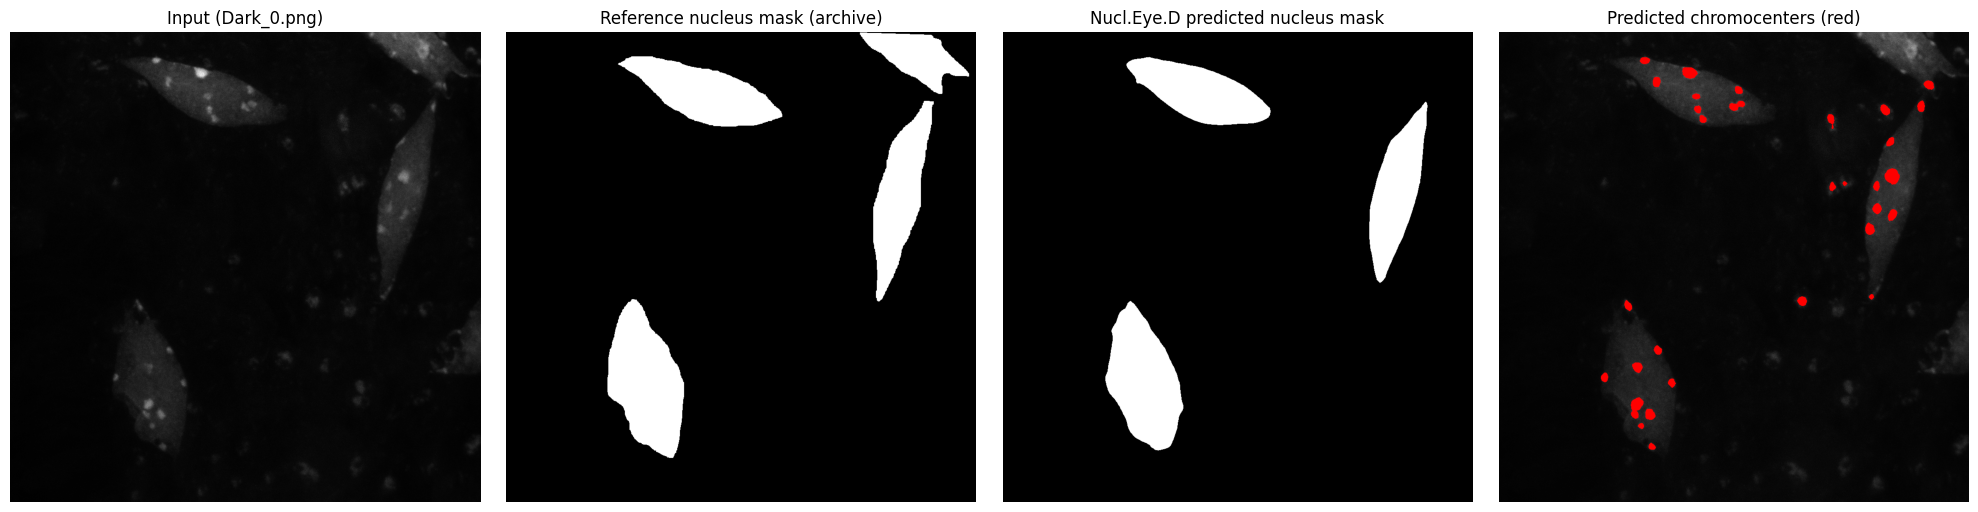

In [ ]:
from skimage.io import imread as sk_imread

def load_mask(path):
    """Reference masks are shipped as grayscale or RGB PNGs; reduce to a single 2-D boolean mask."""
    a = sk_imread(path)
    if a.ndim == 3:
        a = a[..., 0]
    return a > 127

ref_nuc = load_mask("/content/reference_nuc_Dark_0.png")
ref_cc  = load_mask("/content/reference_CC_Dark_0.png")
print("reference mask shapes:", ref_nuc.shape, ref_cc.shape)

def dice(a, b):
    denom = a.sum() + b.sum()
    return float("nan") if denom == 0 else 2.0 * np.logical_and(a, b).sum() / denom

dice_nuc = dice(nuc_mask, ref_nuc)
dice_cc = dice(cc_mask, ref_cc)
print(f"Dice(nucleus prediction vs reference) = {dice_nuc:.3f}")
print(f"Dice(chromocenter prediction vs reference) = {dice_cc:.3f}")

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(img2d, cmap="gray"); ax[0].set_title("Input (Dark_0.png)")
ax[1].imshow(ref_nuc, cmap="gray"); ax[1].set_title("Reference nucleus mask (archive)")
ax[2].imshow(nuc_mask, cmap="gray"); ax[2].set_title("Nucl.Eye.D predicted nucleus mask")
overlay = np.dstack([img2d / max(img2d.max(), 1e-9)] * 3)
overlay[cc_mask] = [1, 0, 0]
ax[3].imshow(np.clip(overlay, 0, 1)); ax[3].set_title("Predicted chromocenters (red)")
for a in ax: a.set_axis_off()
plt.tight_layout()
plt.show()

## Morphometric parameters HF / RHI / RHF (paper Section 3.7)

The paper defines, per nucleus (after z-projection): **HF** = sum of all chromocenter areas / nucleus area; **RHI** = mean intensity in chromocenters / mean intensity in the nucleus; **RHF** = HF × RHI (the proportion of stained DNA present in chromocenters). The authors computed these with the ImageJ macros in `Supplemental Macros.zip` (shown for provenance in the next section); here they are computed in Python from the predicted masks and the original intensities — an **adapted implementation** of the same formulas. The demo field contains **three nuclei**; the table below pools all nuclei of the field (field-level totals), whereas the paper computes the parameters per nucleus and then averages — another documented adaptation. Paper reference points: mean RHF ≈ 15–18% (Light) vs 8–11% (Dark) for user segmentation, and 8–10% vs 4–6% for Nucl.Eye.D masks across >50 nuclei per condition — a single Dark nucleus is not expected to match those means exactly.

**形態計測（JP）：** 論文Section 3.7の定義に従い、予測マスクからHF・RHI・RHFをPythonで計算します（著者はImageJマクロ使用）。

In [ ]:
nucleus_px = int(nuc_mask.sum())
cc_px = int(cc_mask.sum())
HF = cc_px / nucleus_px if nucleus_px else float("nan")
RHI = float(img2d[cc_mask].mean() / img2d[nuc_mask].mean()) if cc_mask.any() and nuc_mask.any() else float("nan")
RHF = HF * RHI
from skimage.measure import label as scikit_label
n_cc_objects = int(scikit_label(cc_mask).max()) if cc_mask.any() else 0

metrics = {
    "sample": ["Dark_0.png"],
    "condition": ["Dark"],
    "nucleus_px": [nucleus_px],
    "chromocenter_px": [cc_px],
    "n_chromocenters": [n_cc_objects],
    "HF": [round(HF, 4)],
    "RHI": [round(RHI, 4)],
    "RHF": [round(RHF, 4)],
    "Dice_nucleus_vs_reference": [round(dice_nuc, 4)],
    "Dice_CC_vs_reference": [round(dice_cc, 4)],
    "thresholds (RP/Nuc/CC)": [f"{RP_threshold}/{Nucleus_threshold}/{CC_threshold}"],
    "inference_s": [round(inference_s, 2)],
    "runtime": ["GPU" if gpus else "CPU"],
}
import pandas as pd
metrics_df = pd.DataFrame(metrics).set_index("sample")
display(metrics_df)
metrics_df.to_csv("/content/NuclEyeD_metrics_Dark_0.csv")
print("metrics saved to /content/NuclEyeD_metrics_Dark_0.csv (inside this Colab VM)")

,condition,nucleus_px,chromocenter_px,n_chromocenters,HF,RHI,RHF,Dice_nucleus_vs_reference,Dice_CC_vs_reference,thresholds (RP/Nuc/CC),inference_s,runtime
sample,,,,,,,,,,,,
Dark_0.png,Dark,87299,10095,31,0.1156,1.7463,0.2019,0.8686,0.6412,0.5/0.5/0.25,2.31,CPU


metrics saved to /content/NuclEyeD_metrics_Dark_0.csv (inside this Colab VM)


## Provenance: the authors' supplemental quantification macros

`Supplemental Macros.zip` (Zenodo 7075507, md5 `b438ce9e488dbe35178899e74aff4089`) contains the ImageJ macros the authors used for quantification. It is downloaded to the Colab VM and only its **text** entries (`.ijm`/`.txt`/`.md`) are listed and displayed (bounded to their first lines) — image content, if any, is not extracted. This documents that the HF/RHI/RHF formulas above follow the paper Section 3.7 definitions.

**出典確認（JP）：** 補足マクロ（ImageJ）をダウンロードし、テキスト部分のみ表示して定義の出典を確認します。

In [ ]:
import zipfile
MACROS_URL = "https://zenodo.org/api/records/7075507/files/Supplemental%20Macros.zip/content"
macros_path = "/content/SupplementalMacros.zip"
with S.get(MACROS_URL, stream=True, timeout=600) as r:
    r.raise_for_status()
    with open(macros_path, "wb") as f:
        for chunk in r.iter_content(1024 * 1024):
            f.write(chunk)
macros_zip = zipfile.ZipFile(macros_path)
text_entries = [n for n in macros_zip.namelist() if n.lower().endswith((".ijm", ".txt", ".md")) and not n.endswith("/")]
print("macro zip entries:", len(macros_zip.namelist()), "| text entries:", len(text_entries))
for n in text_entries:
    print("---", n)
for n in text_entries[:3]:
    head = macros_zip.read(n).decode("utf-8", errors="replace")
    print(f"===== {n} (first 1500 chars) =====")
    print(head[:1500])

macro zip entries: 7 | text entries: 5
--- Supplemental Macros/CCbin.txt
--- Supplemental Macros/compare masks from 2 folders.ijm
--- Supplemental Macros/MacroQuantif.ijm
--- Supplemental Macros/MacroSepNuc2.ijm
--- Supplemental Macros/MacroSepNuc2+Watershed.ijm
===== Supplemental Macros/CCbin.txt (first 1500 chars) =====
run("8-bit");
setAutoThreshold("Default dark no-reset");
//run("Threshold...");
//setThreshold(1, 255);
setOption("BlackBackground", false);
run("Convert to Mask");
===== Supplemental Macros/compare masks from 2 folders.ijm (first 1500 chars) =====
run("Fresh Start");
run("Options...", "iterations=1 count=1 do=Nothing");
run("Set Measurements...", "mean standard min bounding display redirect=None decimal=3");
Dialog.create("Compare masks");
Dialog.addDirectory("folder1", "/Users/jmutterer/Downloads/Jerome/masks1");
Dialog.addDirectory("folder2", "/Users/jmutterer/Downloads/Jerome/masks2");
Dialog.show();

dir1 = Dialog.getString()+File.separator;
dir2 = Dialog.getStri

## Interpretation, limitations and references

**What was reproduced:** the authors' released Nucl.Eye.D cascade (RPN → NM → CC U-Nets, Zenodo 7075507) ran **unmodified in its scientific operations** on one archive-shipped test image, and the paper's Section 3.7 morphometric parameters were computed from the predicted masks. This Dark-condition field contains **three nuclei** (the RPN proposed three regions) and the pipeline segmented all of them, detecting 31 chromocenter objects; the metrics above are pooled over the field (HF ≈ 0.116, RHI ≈ 1.75, RHF ≈ 0.202 as measured in this run) and the predicted nucleus masks agreed well with the archive's reference masks (Dice ≈ 0.87 nuclei / ≈ 0.64 chromocenters, printed above). Values from one field are expected to scatter widely around the paper's dataset means (Dark RHF mean 4–6% with Nucl.Eye.D across >50 nuclei per condition) — consistent with the large per-nucleus spread visible in the paper's violin plots (Figure 6).

**Limitations:** (1) one image, one condition — no dataset-level Light/Dark or ddm1 statistics, no significance tests; (2) the reference masks in the archive are treated as *reference*, not ground truth, and their annotator identity is not stated in the paper; (3) the HF/RHI/RHF computation is a Python port of the Section 3.7 formulas while the authors used ImageJ macros on z-projections (this input is already a z-max projection, so no additional projection was applied); (4) iCRAQ (the ImageJ macro tool) and model training are not part of this demo; (5) the archive's model format required the `tf-keras` legacy loader on current Colab TensorFlow.

**References:** paper DOI [10.3390/epigenomes6040034](https://doi.org/10.3390/epigenomes6040034) (PMC9624336, CC BY); tool release Zenodo [7075507](https://zenodo.org/records/7075507) (CC BY-4.0, version of 2022-09-13; the 2024-04-08 update only adds separate histone-mark models); author release notebook `The_Nucl_Eye_D.ipynb` (md5 `bbd38dc22148a1fa91310822fc3f775c`).

**結果の解釈と限界（JP）：** 著者公開の学習済みパイプラインをアーカイブ同梱のテスト画像1枚に実行し、Section 3.7の定義でHF/RHI/RHFを計算しました。単一例のため論文のデータセット平均（Dark条件のRHF平均4–6%）からのばらつきは当然あります。iCRAQ・学習・データセット統計は対象外です。